# Load Data

In [11]:
import pandas as pd

training_data = pd.read_csv('train.csv')
print(training_data.shape)
display(training_data.head())
training_data.info()

(31112, 16)


,geological_era,weather_pattern,region,aptitude_score,performance_score,stability_index,personal_interest,load_ratio,brew_preference,instrument,species,index_weight,mineral_type,activity_duration,composite_rank,label
0,Triassic,Heatwave,Texas,325.58,34.95,1.503,Foraging,23.878,Espresso,Dulcimer,Lynx,8.63,Marble,77.98,2.093,no
1,Triassic,Monsoon,Texas,333.63,256.50,3.283,Falconry,28.617,Espresso,Cello,Bison,14.22,Opal,95.76,3.028,no
2,Triassic,Monsoon,Texas,503.96,385.00,3.676,Astronomy,22.582,Espresso,Cello,Lynx,11.04,Diamond,114.03,4.564,yes
3,Triassic,Heatwave,Texas,404.61,156.44,2.812,Calligraphy,28.002,Latte,Oboe,Lynx,15.64,Sapphire,113.58,3.053,no
4,Triassic,Heatwave,Texas,358.89,144.05,2.735,Beekeeping,22.062,Espresso,Oboe,Lynx,10.99,Granite,79.40,2.730,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31112 entries, 0 to 31111
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   geological_era     31110 non-null  object 
 1   weather_pattern    31109 non-null  object 
 2   region             31108 non-null  object 
 3   aptitude_score     31108 non-null  float64
 4   performance_score  31110 non-null  float64
 5   stability_index    31110 non-null  float64
 6   personal_interest  31106 non-null  object 
 7   load_ratio         31110 non-null  float64
 8   brew_preference    31105 non-null  object 
 9   instrument         31109 non-null  object 
 10  species            31109 non-null  object 
 11  index_weight       31109 non-null  float64
 12  mineral_type       31109 non-null  object 
 13  activity_duration  31110 non-null  float64
 14  composite_rank     31111 non-null  float64
 15  label              31109 non-null  object 
dtypes: float64(7), object(

# Data Exploration

In [16]:
# Target distribution
print("Target Distribution:")
print(training_data["label"].value_counts())
print(training_data["label"].value_counts(normalize=True))

# Missing values
print("\nMissing Values:")
print(training_data.isnull().sum())

# Numerical summary
print("\nNumerical Features:")
display(training_data.describe())

# Categorical summary
categorical_columns = training_data.select_dtypes(include="object").columns.drop("label")

for column in categorical_columns:
    print(f"\n{column}")
    print("Number of categories:", training_data[column].nunique())
    print(training_data[column].value_counts(dropna=False).head())

Target Distribution:
label
no     23645
yes     7464
Name: count, dtype: int64
label
no     0.760069
yes    0.239931
Name: proportion, dtype: float64

Missing Values:
geological_era       2
weather_pattern      3
region               4
aptitude_score       4
performance_score    2
stability_index      2
personal_interest    6
load_ratio           2
brew_preference      7
instrument           3
species              3
index_weight         3
mineral_type         3
activity_duration    2
composite_rank       1
label                3
dtype: int64

Numerical Features:


,aptitude_score,performance_score,stability_index,load_ratio,index_weight,activity_duration,composite_rank
count,31108.00000,31110.000000,31110.000000,31110.000000,31109.000000,31110.000000,31111.000000
mean,342.13448,296.492726,3.156426,24.422677,12.721826,80.360618,3.238771
std,68.92509,187.620357,0.849307,9.920133,7.747198,25.515080,0.869784
min,90.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.589000
25%,310.59750,146.572500,2.751000,19.272000,7.520000,72.740000,2.591000
50%,333.51500,275.385000,3.351000,23.689000,11.730000,80.330000,3.199000
75%,402.56250,420.170000,3.761750,27.656750,16.230000,90.257500,3.838000
max,510.00000,1010.000000,4.625000,143.717000,99.620000,205.000000,6.876000



geological_era
Number of categories: 5
geological_era
Triassic    26642
Jurassic     2934
Devonian      984
Cambrian      298
Permian       252
Name: count, dtype: int64

weather_pattern
Number of categories: 7
weather_pattern
Monsoon     14274
Heatwave    10251
Blizzard     4191
Fog           987
Frost         978
Name: count, dtype: int64

region
Number of categories: 21
region
Texas           27915
Arizona           608
Wyoming           553
Other             532
South-Dakota      178
Name: count, dtype: int64

personal_interest
Number of categories: 11
personal_interest
Astronomy      3965
Beekeeping     3955
Falconry       3877
Archery        3559
Calligraphy    3443
Name: count, dtype: int64

brew_preference
Number of categories: 2
brew_preference
Espresso    20777
Latte       10328
NaN             7
Name: count, dtype: int64

instrument
Number of categories: 6
instrument
Cello       12573
Oboe         8065
Dulcimer     4780
Theremin     3236
Zither       1491
Name: count, dtype

# Data Processing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Remove rows with missing labels
training_data = training_data.dropna(subset=["label"])

# Separate features and target
X = training_data.drop(columns=["label"])
y = training_data["label"]

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Preprocessing for numerical features
numerical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("onehot", OneHotEncoder(handle_unknown="ignore"))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(transformers=[("num", numerical_transformer, numerical_features),("cat", categorical_transformer, categorical_features)])

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

Training set: (24887, 15)
Validation set: (6222, 15)


# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

decision_tree_model = Pipeline(steps=[("preprocessor", preprocessor),("classifier", DecisionTreeClassifier(random_state=42))])

decision_tree_model.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


# Decision Tree Evaluation

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

decision_tree_predictions = decision_tree_model.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, decision_tree_predictions):.3f}")
print(f"Precision: {precision_score(y_val, decision_tree_predictions, pos_label='yes'):.3f}")
print(f"Recall: {recall_score(y_val, decision_tree_predictions, pos_label='yes'):.3f}")
print(f"F1 Score: {f1_score(y_val, decision_tree_predictions, pos_label='yes'):.3f}")

cm = confusion_matrix(y_val, decision_tree_predictions, labels=["no", "yes"])

cm_df = pd.DataFrame(cm, index=["Actual no", "Actual yes"], columns=["Predicted no", "Predicted yes"])

display(cm_df)

Accuracy: 0.775
Precision: 0.529
Recall: 0.547
F1 Score: 0.538


,Predicted no,Predicted yes
Actual no,4002,727
Actual yes,676,817


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[("preprocessor", preprocessor),("classifier", RandomForestClassifier(n_estimators=100,random_state=42))])

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


# Random Forest Evaluation

In [26]:
random_forest_predictions = random_forest_model.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, random_forest_predictions):.3f}")
print(f"Precision: {precision_score(y_val, random_forest_predictions, pos_label='yes'):.3f}")
print(f"Recall: {recall_score(y_val, random_forest_predictions, pos_label='yes'):.3f}")
print(f"F1 Score: {f1_score(y_val, random_forest_predictions, pos_label='yes'):.3f}")

cm = confusion_matrix(y_val, random_forest_predictions, labels=["no", "yes"])

cm_df = pd.DataFrame(cm, index=["Actual no", "Actual yes"],columns=["Predicted no", "Predicted yes"])

display(cm_df)

Accuracy: 0.826
Precision: 0.673
Recall: 0.533
F1 Score: 0.595


,Predicted no,Predicted yes
Actual no,4343,386
Actual yes,697,796


# Model Comparison

In [27]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_val, decision_tree_predictions),
        accuracy_score(y_val, random_forest_predictions)
    ],
    "Precision": [
        precision_score(y_val, decision_tree_predictions, pos_label="yes"),
        precision_score(y_val, random_forest_predictions, pos_label="yes")
    ],
    "Recall": [
        recall_score(y_val, decision_tree_predictions, pos_label="yes"),
        recall_score(y_val, random_forest_predictions, pos_label="yes")
    ],
    "F1 Score": [
        f1_score(y_val, decision_tree_predictions, pos_label="yes"),
        f1_score(y_val, random_forest_predictions, pos_label="yes")
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.775,0.529,0.547,0.538
1,Random Forest,0.826,0.673,0.533,0.595


# Hyperparameter Tuning

## Decision Tree

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Use F1 score for the positive class "yes"
f1_scorer = make_scorer(f1_score, pos_label="yes")

# Build Decision Tree pipeline
decision_tree_tuning = Pipeline(steps=[("preprocessor", preprocessor),("classifier", DecisionTreeClassifier(random_state=42))])

# Hyperparameter candidates
decision_tree_params = {"classifier__max_depth": [3, 5, 10, 15, None]}

# Grid Search with 5-fold cross-validation
decision_tree_grid = GridSearchCV(decision_tree_tuning,param_grid=decision_tree_params,cv=5,scoring=f1_scorer,n_jobs=-1)

# Train and tune
decision_tree_grid.fit(X_train, y_train)

print("Best max_depth:", decision_tree_grid.best_params_)
print("Best CV F1 Score:", round(decision_tree_grid.best_score_, 3))

# Evaluate the best model on validation data
best_decision_tree = decision_tree_grid.best_estimator_
tuned_dt_predictions = best_decision_tree.predict(X_val)

print(f"\nAccuracy: {accuracy_score(y_val, tuned_dt_predictions):.3f}")
print(f"Precision: {precision_score(y_val, tuned_dt_predictions, pos_label='yes'):.3f}")
print(f"Recall: {recall_score(y_val, tuned_dt_predictions, pos_label='yes'):.3f}")
print(f"F1 Score: {f1_score(y_val, tuned_dt_predictions, pos_label='yes'):.3f}")

# Confusion Matrix
cm = confusion_matrix(y_val, tuned_dt_predictions, labels=["no", "yes"])

cm_df = pd.DataFrame(cm,index=["Actual no", "Actual yes"],columns=["Predicted no", "Predicted yes"])

display(cm_df)

Best max_depth: {'classifier__max_depth': 10}
Best CV F1 Score: 0.606

Accuracy: 0.822
Precision: 0.655
Recall: 0.547
F1 Score: 0.596


,Predicted no,Predicted yes
Actual no,4298,431
Actual yes,676,817


## Random Forest

In [ ]:
random_forest_tuning = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", RandomForestClassifier(random_state=42))])

random_forest_params = {"classifier__n_estimators": [100, 200], "classifier__max_depth": [10, 15, None]}

random_forest_grid = GridSearchCV(random_forest_tuning,param_grid=random_forest_params,cv=5,scoring=f1_scorer,n_jobs=-1)

random_forest_grid.fit(X_train, y_train)

print("Best parameters:", random_forest_grid.best_params_)
print("Best CV F1 Score:", round(random_forest_grid.best_score_, 3))

best_random_forest = random_forest_grid.best_estimator_
tuned_rf_predictions = best_random_forest.predict(X_val)

print(f"\nAccuracy: {accuracy_score(y_val, tuned_rf_predictions):.3f}")
print(f"Precision: {precision_score(y_val, tuned_rf_predictions, pos_label='yes'):.3f}")
print(f"Recall: {recall_score(y_val, tuned_rf_predictions, pos_label='yes'):.3f}")
print(f"F1 Score: {f1_score(y_val, tuned_rf_predictions, pos_label='yes'):.3f}")

cm = confusion_matrix(y_val, tuned_rf_predictions, labels=["no", "yes"])

cm_df = pd.DataFrame(cm,index=["Actual no", "Actual yes"],columns=["Predicted no", "Predicted yes"])

display(cm_df)

Best parameters: {'classifier__max_depth': 15, 'classifier__n_estimators': 100}
Best CV F1 Score: 0.624

Accuracy: 0.832
Precision: 0.696
Recall: 0.531
F1 Score: 0.602


,Predicted no,Predicted yes
Actual no,4382,347
Actual yes,700,793


## Final Model Comparison

In [31]:
final_comparison = pd.DataFrame({
    "Model": ["Tuned Decision Tree", "Tuned Random Forest"],
    "Accuracy": [
        accuracy_score(y_val, tuned_dt_predictions),
        accuracy_score(y_val, tuned_rf_predictions)
    ],
    "Precision": [
        precision_score(y_val, tuned_dt_predictions, pos_label="yes"),
        precision_score(y_val, tuned_rf_predictions, pos_label="yes")
    ],
    "Recall": [
        recall_score(y_val, tuned_dt_predictions, pos_label="yes"),
        recall_score(y_val, tuned_rf_predictions, pos_label="yes")
    ],
    "F1 Score": [
        f1_score(y_val, tuned_dt_predictions, pos_label="yes"),
        f1_score(y_val, tuned_rf_predictions, pos_label="yes")
    ]
})

display(final_comparison.round(3))

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Decision Tree,0.822,0.655,0.547,0.596
1,Tuned Random Forest,0.832,0.696,0.531,0.602


# Final Test Evaluation

Final Test Results:


,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Decision Tree,0.825,0.643,0.597,0.619
1,Tuned Random Forest,0.839,0.708,0.550,0.619


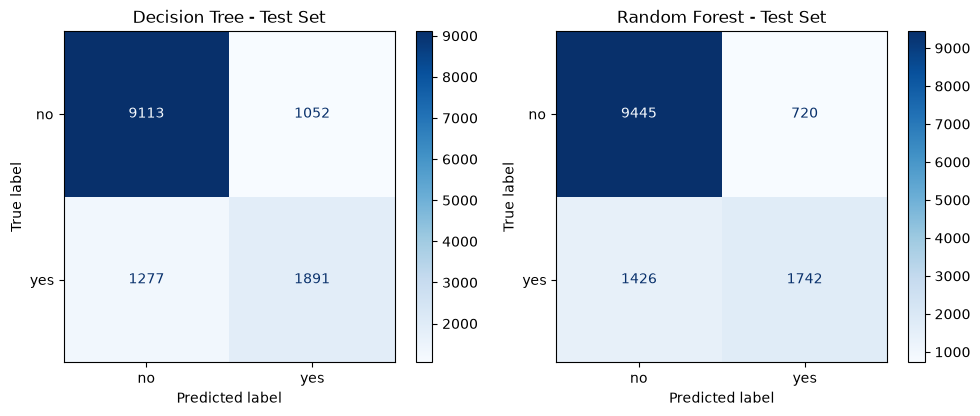

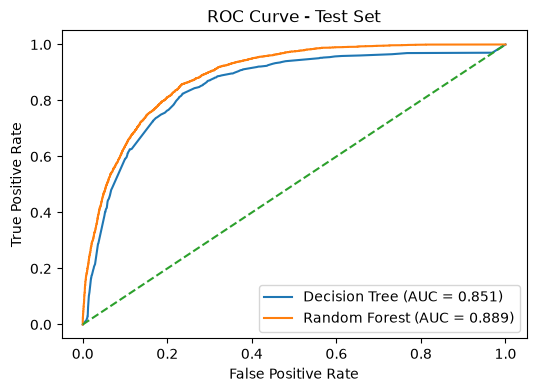

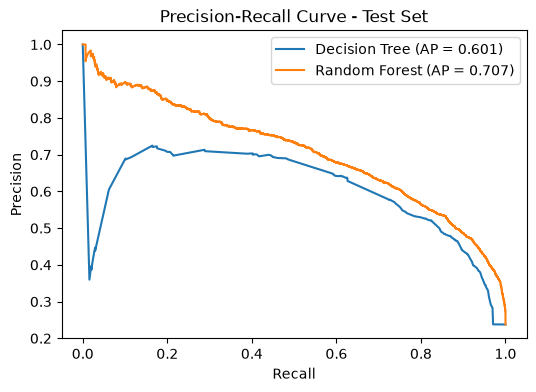

Results saved to results.json


In [38]:
import json

# Load test data
test_data = pd.read_csv("test.csv")

# Remove rows with missing labels
test_data = test_data.dropna(subset=["label"])

# Separate features and target
X_test = test_data.drop(columns=["label"])
y_test = test_data["label"]

# Retrain tuned models using the full training dataset
best_decision_tree.fit(X, y)
best_random_forest.fit(X, y)

# Make predictions
dt_test_predictions = best_decision_tree.predict(X_test)
rf_test_predictions = best_random_forest.predict(X_test)

# Get predicted probabilities for "yes"
dt_test_prob = best_decision_tree.predict_proba(X_test)[:, 1]
rf_test_prob = best_random_forest.predict_proba(X_test)[:, 1]


# Performance Metrics
dt_test_accuracy = accuracy_score(y_test, dt_test_predictions)
dt_test_precision = precision_score(y_test,dt_test_predictions,pos_label="yes")
dt_test_recall = recall_score(y_test,dt_test_predictions,pos_label="yes")
dt_test_f1 = f1_score(y_test,dt_test_predictions,pos_label="yes")

rf_test_accuracy = accuracy_score(y_test, rf_test_predictions)
rf_test_precision = precision_score(y_test,rf_test_predictions,pos_label="yes")
rf_test_recall = recall_score(y_test,rf_test_predictions,pos_label="yes")
rf_test_f1 = f1_score(y_test,rf_test_predictions,pos_label="yes")

test_comparison = pd.DataFrame({"Model": ["Tuned Decision Tree","Tuned Random Forest"], "Accuracy": [dt_test_accuracy,rf_test_accuracy], "Precision": [dt_test_precision,rf_test_precision], "Recall": [dt_test_recall,rf_test_recall],"F1 Score": [dt_test_f1,rf_test_f1]})

print("Final Test Results:")
display(test_comparison.round(3))


# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(y_test,dt_test_predictions,labels=["no", "yes"],display_labels=["no", "yes"],ax=axes[0],cmap="Blues")

axes[0].set_title("Decision Tree - Test Set")

ConfusionMatrixDisplay.from_predictions(y_test,rf_test_predictions,labels=["no", "yes"],display_labels=["no", "yes"],ax=axes[1],cmap="Blues")

axes[1].set_title("Random Forest - Test Set")

plt.tight_layout()
plt.show()


# ROC Curve
dt_test_fpr, dt_test_tpr, _ = roc_curve(y_test,dt_test_prob,pos_label="yes")

rf_test_fpr, rf_test_tpr, _ = roc_curve(y_test,rf_test_prob,pos_label="yes")

dt_test_auc = roc_auc_score((y_test == "yes").astype(int),dt_test_prob)

rf_test_auc = roc_auc_score((y_test == "yes").astype(int),rf_test_prob)

plt.figure(figsize=(6, 4))

plt.plot(dt_test_fpr,dt_test_tpr,label=f"Decision Tree (AUC = {dt_test_auc:.3f})")

plt.plot(rf_test_fpr,rf_test_tpr,label=f"Random Forest (AUC = {rf_test_auc:.3f})")

plt.plot([0, 1],[0, 1],linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()

plt.show()


# Precision-Recall Curve
dt_test_precision_curve, dt_test_recall_curve, _ = precision_recall_curve(y_test,dt_test_prob,pos_label="yes")

rf_test_precision_curve, rf_test_recall_curve, _ = precision_recall_curve(y_test,rf_test_prob,pos_label="yes")

dt_test_ap = average_precision_score((y_test == "yes").astype(int),dt_test_prob)

rf_test_ap = average_precision_score((y_test == "yes").astype(int),rf_test_prob)

plt.figure(figsize=(6, 4))

plt.plot(dt_test_recall_curve,dt_test_precision_curve,label=f"Decision Tree (AP = {dt_test_ap:.3f})")

plt.plot(rf_test_recall_curve,rf_test_precision_curve,label=f"Random Forest (AP = {rf_test_ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test Set")
plt.legend()

plt.show()

# Save Test Results
dt_confusion = confusion_matrix(y_test,dt_test_predictions,labels=["no", "yes"]).tolist()

rf_confusion = confusion_matrix(y_test,rf_test_predictions,labels=["no", "yes"]).tolist()

results = {
    "DecisionTree": {
        "best_params": decision_tree_grid.best_params_,
        "cv_f1": round(decision_tree_grid.best_score_, 3),
        "test": {
            "accuracy": round(dt_test_accuracy, 3),
            "precision": round(dt_test_precision, 3),
            "recall": round(dt_test_recall, 3),
            "f1": round(dt_test_f1, 3),
            "roc_auc": round(dt_test_auc, 3),
            "average_precision": round(dt_test_ap, 3)
        },
        "confusion_matrix": dt_confusion
    },

    "RandomForest": {
        "best_params": random_forest_grid.best_params_,
        "cv_f1": round(random_forest_grid.best_score_, 3),
        "test": {
            "accuracy": round(rf_test_accuracy, 3),
            "precision": round(rf_test_precision, 3),
            "recall": round(rf_test_recall, 3),
            "f1": round(rf_test_f1, 3),
            "roc_auc": round(rf_test_auc, 3),
            "average_precision": round(rf_test_ap, 3)
        },
        "confusion_matrix": rf_confusion
    }
}

with open("results.json", "w") as file:
    json.dump(results, file, indent=4)

print("Results saved to results.json")